In [15]:
import pandas as pd 
import numpy as np

#importing datatset
df = pd.read_csv('IMDB Dataset.csv')
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
#Checking dataset info 
print(df.describe())
print("-------------------------------")
print(df.info())

                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000
-------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [4]:
#Sentiment count
print(f"Total: \n{df['sentiment'].value_counts()}")

Total: 
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [7]:
review = []

sentences = list(df['review'])
for sentence in sentences:
    review.append(sentence)

labels = df['sentiment']
labels = np.array(list(map(lambda x: 1 if x == 'positive' else 0, labels)))

In [10]:
from sklearn.model_selection import train_test_split

train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.2, random_state=42)

#Parametros 
vocab_size = 1000
max_length = 120
embedding_dim = 16
trunc_type = 'post'
oov_tok = "<OOV>"

In [22]:
import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
import keras

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Qué métrica observar (usualmente la pérdida de validación)
    patience=5,             # Cuántas épocas esperar tras la última mejora
    verbose=1,              # Muestra un mensaje cuando se detiene
    restore_best_weights=True # ¡Importante! Devuelve los pesos del mejor momento
)

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences, maxlen=max_length, truncating=trunc_type)

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

In [23]:
#Construir modelo 
model = keras.Sequential([
    keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    keras.layers.Flatten(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

c:\Users\714KQ54\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7341 - loss: 0.5136 - val_accuracy: 0.8182 - val_loss: 0.4020
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - accuracy: 0.8171 - loss: 0.4063 - val_accuracy: 0.7934 - val_loss: 0.4358
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step - accuracy: 0.8389 - loss: 0.3639 - val_accuracy: 0.7919 - val_loss: 0.4506
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 968us/step - accuracy: 0.8602 - loss: 0.3226 - val_accuracy: 0.7963 - val_loss: 0.4650
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 957us/step - accuracy: 0.8781 - loss: 0.2857 - val_accuracy: 0.7873 - val_loss: 0.5176
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 957us/step - accuracy: 0.8936 - loss: 0.2506 - val_accuracy: 0.7855 - val_loss: 0.5487
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


<Axes: >

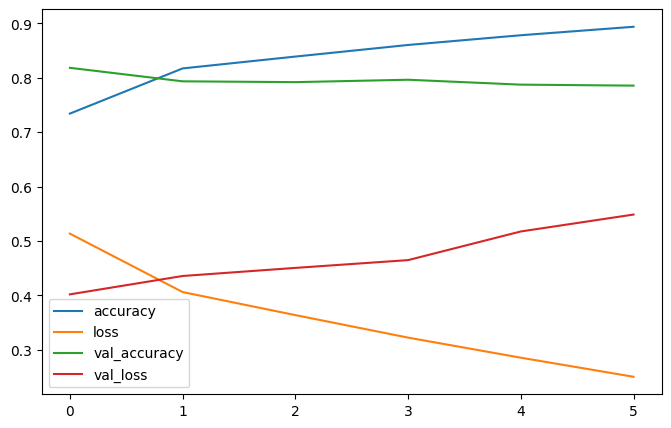

In [24]:
#Entrenar modelo 
history = model.fit(padded, 
                    train_labels, 
                    epochs=30, 
                    validation_data=(test_padded, test_labels),
                    callbacks=[early_stopping])
pd.DataFrame(history.history).plot(figsize=(8,5))